In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Loading Data

In [ ]:
property_dfs = []

dir_path = '/content/drive/MyDrive/property_data'

for path in os.listdir(dir_path):
    property_dfs.append(pd.read_csv(os.path.join(dir_path, path), low_memory=False))

property_data_2025 = pd.concat(property_dfs, ignore_index=True)

property_data_2025 = property_data_2025[(property_data_2025['PropertyType'] == 'Residential') & (property_data_2025['PropertySubType'] == 'SingleFamilyResidence')]

In [ ]:
lower_bound_close_price = property_data_2025['ClosePrice'].quantile(.005)
upper_bound_close_price = property_data_2025['ClosePrice'].quantile(.995)

property_data_2025 = property_data_2025[(property_data_2025['ClosePrice'] > lower_bound_close_price) & (property_data_2025['ClosePrice'] < upper_bound_close_price)]

## 1. Data Loading

In [ ]:
initial_rows = len(property_data_2025)

property_data_2025.dropna(subset=['ClosePrice'], inplace=True)
property_data_2025['CloseDate'] = pd.to_datetime(property_data_2025['CloseDate'])
property_data_2025.drop_duplicates(inplace=True)

valid_data_mask = (
    (property_data_2025['ClosePrice'] > 0) &             # Price must be positive
    (property_data_2025['LivingArea'] > 100) &           # Living area should be realistic (>100 sqft)
    (property_data_2025['BedroomsTotal'] > 0) &          # At least 1 bedroom for Residential
    (property_data_2025['BathroomsTotalInteger'] > 0)    # Must have a bathroom
)

property_data_2025 = property_data_2025[valid_data_mask].copy()
rows_removed = initial_rows - len(property_data_2025)

print(f"Cleaning Complete.")
print(f"Rows removed due to logic errors: {rows_removed}")
print(f"Remaining clean records: {len(property_data_2025)}")

Cleaning Complete.
Rows removed due to logic errors: 185
Remaining clean records: 128720


In [ ]:
columns_to_keep = [
    'ClosePrice', 'BuyerAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN',
    'PoolPrivateYN', 'LivingArea', 'CloseDate', 'BathroomsTotalInteger','LotSizeAcres',
    'BuyerOfficeName', 'CoListOfficeName', 'FireplacesTotal', 'AssociationFeeFrequency',
    'AssociationFee', 'AboveGradeFinishedArea', 'MLSAreaMajor', 'TaxAnnualAmount',
    'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'YearBuilt', 'City', 'TaxYear', 'NewConstructionYN',
    'BuildingAreaTotal', 'BedroomsTotal', 'BelowGradeFinishedArea', 'Stories', 'MainLevelBedrooms',
    'PostalCode', 'LotSizeSquareFeet'
]
property_data_2025 = property_data_2025[columns_to_keep]

In [ ]:
property_data_2025.head()

,ClosePrice,BuyerAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,CloseDate,BathroomsTotalInteger,...,City,TaxYear,NewConstructionYN,BuildingAreaTotal,BedroomsTotal,BelowGradeFinishedArea,Stories,MainLevelBedrooms,PostalCode,LotSizeSquareFeet
0,1250000.0,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1027.0,2025-11-30,2.0,...,Huntington Beach,NaN,False,NaN,3.0,NaN,1.0,3.0,92646,5913.0
1,2299995.0,Mlslistings,Carpet,False,NaN,NaN,NaN,1129.0,2025-11-20,1.0,...,San Jose,NaN,False,NaN,3.0,NaN,NaN,NaN,95124,18432.0
2,810000.0,PacificSouthwest,NaN,False,NaN,NaN,False,1619.0,2025-11-26,3.0,...,San Ysidro,NaN,NaN,NaN,4.0,NaN,2.0,0.0,92173,5300.0
3,925000.0,PacificSouthwest,NaN,False,NaN,NaN,False,2872.0,2025-11-17,3.0,...,San Diego,NaN,NaN,NaN,5.0,NaN,2.0,1.0,92154,5272.0
4,1300000.0,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1727.0,2025-11-25,2.0,...,Templeton,NaN,False,NaN,3.0,NaN,1.0,3.0,93465,10500.0


# Distribution Plots

## 2. Data Cleaning & Preprocessing

<Axes: ylabel='Density'>

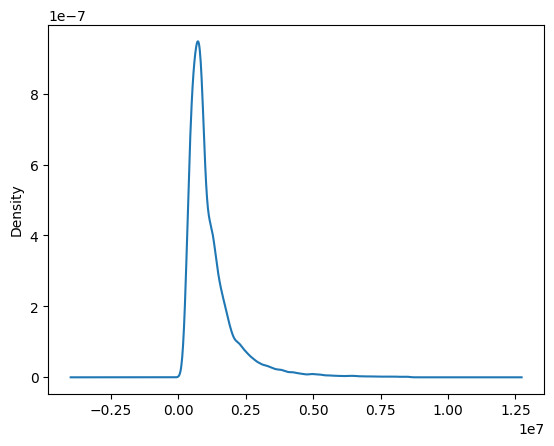

In [ ]:
property_data_2025['ClosePrice'].plot.kde()

<Axes: ylabel='Density'>

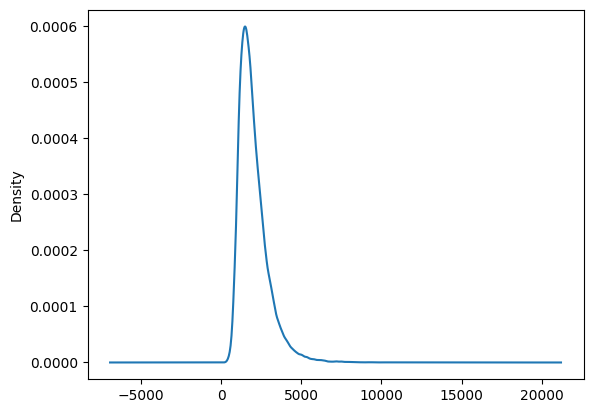

In [ ]:
property_data_2025['LivingArea'].plot.kde()

<Axes: ylabel='Density'>

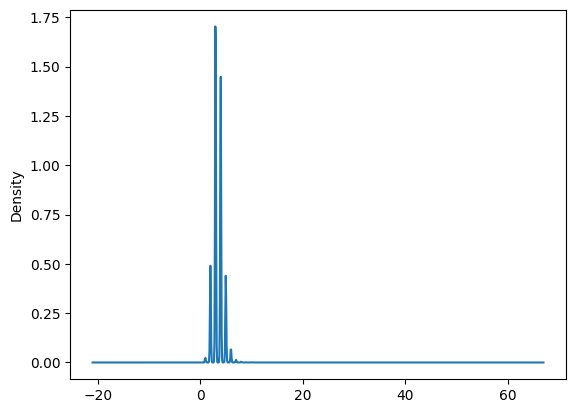

In [ ]:
property_data_2025['BedroomsTotal'].plot.kde()

<Axes: ylabel='Density'>

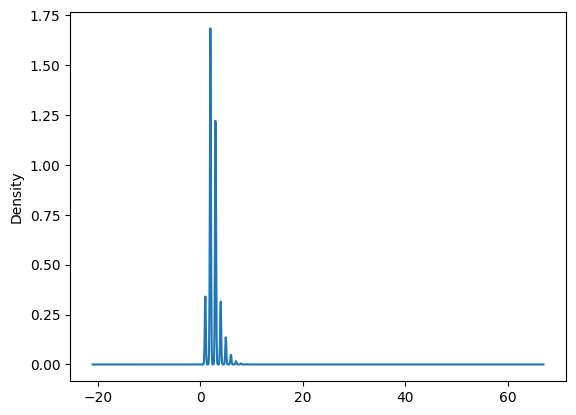

In [ ]:
property_data_2025['BathroomsTotalInteger'].plot.kde()

<Axes: ylabel='Density'>

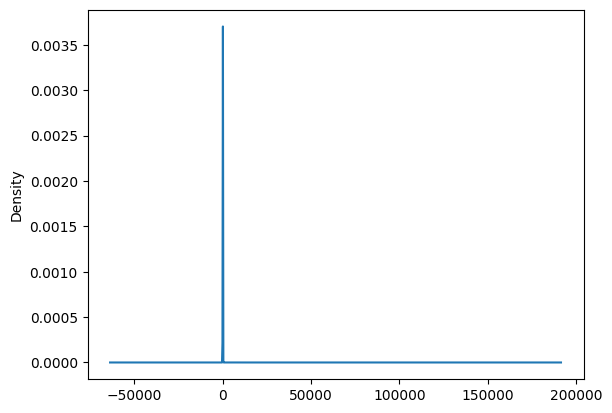

In [ ]:
property_data_2025['LotSizeAcres'].plot.kde()

## 3. Train-Test Split

# Correlation Heatmap

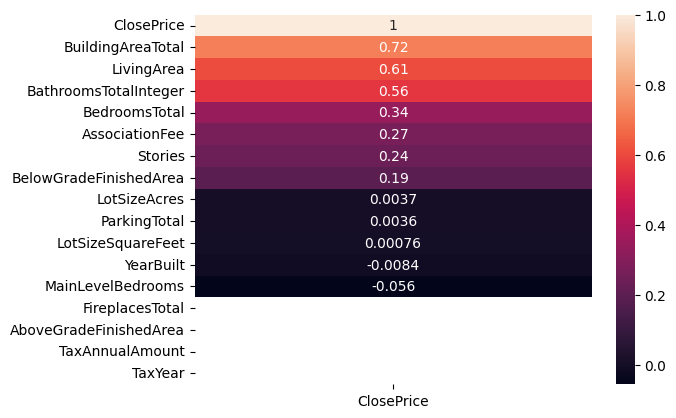

In [ ]:
corr_matrix = property_data_2025.corr(numeric_only=True)['ClosePrice'].sort_values(ascending=False).to_frame()
sns.heatmap(corr_matrix, annot=True)
plt.show()

# Column Information

In [ ]:
property_data_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128720 entries, 0 to 260100
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   ClosePrice               128720 non-null  float64       
 1   BuyerAgentAOR            128704 non-null  object        
 2   Flooring                 83177 non-null   object        
 3   ViewYN                   116910 non-null  object        
 4   WaterfrontYN             64 non-null      object        
 5   BasementYN               3039 non-null    object        
 6   PoolPrivateYN            118660 non-null  object        
 7   LivingArea               128720 non-null  float64       
 8   CloseDate                128720 non-null  datetime64[ns]
 9   BathroomsTotalInteger    128720 non-null  float64       
 10  LotSizeAcres             126492 non-null  float64       
 11  BuyerOfficeName          127117 non-null  object        
 12  CoListOfficeName     

In [ ]:
property_data_2025.describe()

,ClosePrice,LivingArea,CloseDate,BathroomsTotalInteger,LotSizeAcres,FireplacesTotal,AssociationFee,AboveGradeFinishedArea,TaxAnnualAmount,ParkingTotal,YearBuilt,TaxYear,BuildingAreaTotal,BedroomsTotal,BelowGradeFinishedArea,Stories,MainLevelBedrooms,LotSizeSquareFeet
count,1.287200e+05,128720.000000,128720,128720.000000,126492.000000,0.0,91168.000000,0.0,0.0,128719.000000,128662.000000,0.0,8317.000000,128720.000000,880.000000,114945.000000,78391.000000,1.264900e+05
mean,1.193936e+06,2023.003398,2025-07-05 22:27:26.960845056,2.610333,13.406706,NaN,100.881087,NaN,NaN,3.108045,1975.677162,NaN,2307.268967,3.484268,60.247727,1.350463,2.278195,3.184167e+05
min,1.900000e+05,105.000000,2025-01-01 00:00:00,1.000000,0.000000,NaN,0.000000,NaN,NaN,-143.000000,1776.000000,NaN,352.000000,1.000000,0.000000,1.000000,0.000000,0.000000e+00
25%,6.270000e+05,1385.000000,2025-04-14 00:00:00,2.000000,0.130000,NaN,0.000000,NaN,NaN,2.000000,1956.000000,NaN,1475.000000,3.000000,0.000000,1.000000,1.000000,5.663000e+03
50%,8.889435e+05,1811.000000,2025-07-07 00:00:00,2.000000,0.166700,NaN,0.000000,NaN,NaN,2.000000,1976.000000,NaN,1997.000000,3.000000,0.000000,1.000000,3.000000,7.260000e+03
75%,1.400000e+06,2421.000000,2025-09-30 00:00:00,3.000000,0.238400,NaN,130.000000,NaN,NaN,3.000000,1998.000000,NaN,2800.000000,4.000000,0.000000,2.000000,3.000000,1.037900e+04
max,8.550000e+06,14168.000000,2025-12-31 00:00:00,45.000000,127631.000000,NaN,14129.000000,NaN,NaN,15720.000000,2026.000000,NaN,12124.000000,45.000000,3437.000000,2.000000,444.000000,2.087221e+09
std,9.637713e+05,944.196578,NaN,1.078205,796.204670,NaN,292.595894,NaN,NaN,53.103639,27.519958,NaN,1218.411149,0.951827,269.563495,0.477117,2.133750,1.555399e+07


## 4. Feature Engineering

# Missing Data

In [ ]:
property_data_2025.isnull().sum()

,0
ClosePrice,0
BuyerAgentAOR,16
Flooring,45543
ViewYN,11810
WaterfrontYN,128656
BasementYN,125681
PoolPrivateYN,10060
LivingArea,0
CloseDate,0
BathroomsTotalInteger,0


# Categorical Variables

In [ ]:
list(set(property_data_2025.columns) - set(property_data_2025._get_numeric_data().columns))

['CloseDate',
 'ViewYN',
 'PostalCode',
 'BasementYN',
 'City',
 'AttachedGarageYN',
 'WaterfrontYN',
 'BuyerAgentAOR',
 'Flooring',
 'MLSAreaMajor',
 'PoolPrivateYN',
 'BuyerOfficeName',
 'CoListOfficeName',
 'AssociationFeeFrequency',
 'BuilderName',
 'NewConstructionYN']

In [ ]:
for col in property_data_2025[list(set(property_data_2025.columns) - set(property_data_2025._get_numeric_data().columns))].columns:
  print(f'{col}: {len(property_data_2025[col].unique())}')

CloseDate: 363
ViewYN: 3
PostalCode: 2082
BasementYN: 2
City: 967
AttachedGarageYN: 3
WaterfrontYN: 2
BuyerAgentAOR: 54
Flooring: 267
MLSAreaMajor: 1020
PoolPrivateYN: 3
BuyerOfficeName: 12467
CoListOfficeName: 3205
AssociationFeeFrequency: 5
BuilderName: 1392
NewConstructionYN: 3


## 5. Modeling
We compare Linear Regression, Random Forest, and XGBoost, using evaluation metrics of R² (explained variance) and MAPE (prediction error %).

# Splitting into Train and Test sets

In [ ]:
latest_month = property_data_2025['CloseDate'].dt.to_period('M').max()
latest_month

test_set = property_data_2025[
    property_data_2025['CloseDate'].dt.to_period('M') == latest_month
]

train_set = property_data_2025[
    property_data_2025['CloseDate'] < test_set['CloseDate'].min()
]

In [ ]:
print("Train:", len(train_set))
print("Test:", len(test_set))

Train: 118391
Test: 10329


In [ ]:
train_set.columns

Index(['ClosePrice', 'BuyerAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'LivingArea', 'CloseDate',
       'BathroomsTotalInteger', 'LotSizeAcres', 'BuyerOfficeName',
       'CoListOfficeName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AssociationFee', 'AboveGradeFinishedArea', 'MLSAreaMajor',
       'TaxAnnualAmount', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName',
       'YearBuilt', 'City', 'TaxYear', 'NewConstructionYN',
       'BuildingAreaTotal', 'BedroomsTotal', 'BelowGradeFinishedArea',
       'Stories', 'MainLevelBedrooms', 'PostalCode', 'LotSizeSquareFeet'],
      dtype='object')

In [ ]:
features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeSquareFeet',
    'AssociationFee',
    'BuildingAreaTotal',
    'Stories',
    'MainLevelBedrooms',
    'City'
]

X_train = train_set[features]
y_train = train_set['ClosePrice']

X_test = test_set[features]
y_test = test_set['ClosePrice']

city_counts = X_train['City'].value_counts()
top_cities = city_counts[city_counts > 100].index   # keep cities with > 100 homes
X_train['City'] = X_train['City'].where(X_train['City'].isin(top_cities), 'Other')
X_test['City'] = X_test['City'].where(X_test['City'].isin(top_cities), 'Other')

X_train = pd.get_dummies(X_train, columns=['City'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['City'], drop_first=True).reindex(columns=X_train.columns, fill_value=0)

/tmp/ipykernel_2575/772110557.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['City'] = X_train['City'].where(X_train['City'].isin(top_cities), 'Other')
/tmp/ipykernel_2575/772110557.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['City'] = X_test['City'].where(X_test['City'].isin(top_cities), 'Other')


In [ ]:
X_train

,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,AssociationFee,BuildingAreaTotal,Stories,MainLevelBedrooms,City_Adelanto,City_Agoura Hills,...,City_Westlake Village,City_Westminster,City_Whittier,City_Wildomar,City_Winchester,City_Winnetka,City_Woodland Hills,City_Yorba Linda,City_Yucaipa,City_Yucca Valley
0,1027.0,3.0,2.0,5913.0,0.0,NaN,1.0,3.0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1129.0,3.0,1.0,18432.0,NaN,NaN,NaN,NaN,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1619.0,4.0,3.0,5300.0,0.0,NaN,2.0,0.0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2872.0,5.0,3.0,5272.0,55.0,NaN,2.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1727.0,3.0,2.0,10500.0,0.0,NaN,1.0,3.0,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260074,720.0,3.0,1.0,3325.0,NaN,NaN,2.0,NaN,False,False,...,False,False,False,False,False,False,False,False,False,False
260085,1575.0,3.0,2.0,8718.0,NaN,NaN,2.0,NaN,False,False,...,False,False,False,False,False,False,False,False,False,False
260086,1071.0,1.0,3.0,217800.0,0.0,NaN,1.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
260091,2819.0,4.0,4.0,108900.0,0.0,NaN,1.0,4.0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X_train.isna().sum()

,0
LivingArea,0
BedroomsTotal,0
BathroomsTotalInteger,0
LotSizeSquareFeet,2074
AssociationFee,34748
...,...
City_Winnetka,0
City_Woodland Hills,0
City_Yorba Linda,0
City_Yucaipa,0


In [ ]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

## 7. Results & Comparison

## Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("R²:", r2)
print("MAPE:", mape)

R²: 0.6783698579582231
MAPE: 33.801085313552335


## Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("R²:", r2_rf)
print("MAPE:", mape_rf)

R²: 0.7410330960903584
MAPE: 22.90575432236753


# XG Boost

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)

print("XGBoost Results:")
print("R²:", r2_xgb)
print("MAPE:", mape_xgb * 100)

XGBoost Results:
R²: 0.7228810145055077
MAPE: 31.27115287655668
